# Regime Detection Tuning Experiment

A systematic grid search over the regime detection function's hyperparameters and
diagnostic channel subsets to find the configuration that most accurately detects
the true regime boundaries.

## Experimental Variables

| Variable | Values | Rationale |
|----------|--------|-----------|
| **Diagnostic channels** | 7 subsets (see below) | Which rolling RF diagnostics carry the signal vs add noise |
| **PELT penalty** | 3, 4, 5, 6, 7, 8 | Controls sensitivity — too low = spurious breaks, too high = missed breaks |
| **Window size** | 15, 20, 25, 30 | Smaller = faster response but noisier; larger = smoother but delayed |
| **PELT cost model** | rbf, l2 | RBF is distribution-free; L2 assumes mean-shift |
| **min_size** | 5, 10, window_size | Minimum segment length in diagnostic space |

## Evaluation Metrics (per configuration, averaged over 10 seeds)

1. **n_detected** — number of changepoints found (target = 2)
2. **mean_location_error** — mean absolute distance from each detected boundary to the nearest true boundary (lower is better)
3. **ARI** — Adjusted Rand Index of detected labels vs ground truth (higher is better, max = 1.0)
4. **composite_score** — weighted combination: `0.5 * ARI + 0.3 * (1 - norm_location_error) + 0.2 * n_correct_penalty`

## Diagnostic Channel Subsets

| ID | Channels | Hypothesis |
|----|----------|------------|
| `all` | RMSE, R², entropy, resid_mean, resid_std, Jaccard | Full signal — baseline |
| `fit_quality` | RMSE, R², resid_std | Model fit quality only |
| `residuals` | resid_mean, resid_std | Cheapest; residual distribution shift |
| `importance` | entropy, Jaccard | Feature importance structure only |
| `r2_resid` | R², resid_mean, resid_std | R² + residual stats |
| `no_jaccard` | RMSE, R², entropy, resid_mean, resid_std | Drop noisiest channel |
| `r2_only` | R² | Single strongest channel |

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
from itertools import product
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import adjusted_rand_score
import ruptures
import time

warnings.filterwarnings("ignore", category=FutureWarning)
np.random.seed(42)
print("Imports OK")

Imports OK


## 1. Synthetic Data Generator

Inlined from the prototype — generates 150 runs with 3 regimes (changepoints at 50 and 100),
regime-dependent decision coefficients, and ~10% missingness. Parameterised by seed so we
can generate multiple independent datasets for robustness testing.

In [2]:
# ── Toggle data mode ─────────────────────────────────────────────
DATA_MODE = "hard"   # "original" → 3 regimes (50 each)  |  "hard" → 5 regimes (30 each)
# ─────────────────────────────────────────────────────────────────

# ══════════════════════════════════════════════════════════════════
# Coefficient tables  (must match the CSVs exactly)
# ══════════════════════════════════════════════════════════════════

# ---- Original (3 regimes, changepoints at 50, 100) ----
ORIG_DECISION_COEFS = np.array([
    [2.0,  2.0, 2.0],   # R0
    [2.0, -2.0, 2.0],   # R1: decision_1 flips
    [0.5,  2.0, 4.0],   # R2: decision_2 dominant
])
ORIG_STRONG_COEFS = np.array([
    [ 3.0,  3.0, 3.0],
    [ 3.0, -3.0, 3.0],
    [ 3.0,  3.0, 0.5],
])
ORIG_MOD_COEFS = np.array([
    [1.0, 1.0],
    [0.0, 1.0],
    [0.0, 1.0],
])
ORIG_CHANGEPOINTS = [50, 100]
ORIG_NOISE_SD     = 1.5          # homoscedastic
ORIG_NONLINEAR_AMP = 2.0        # same for all regimes
ORIG_PROXY_COEF    = 1.5        # same for all regimes
ORIG_AMBIENT_COEFS = [0.5, 0.8, 1.1]   # (0.5 + 0.3*r)/10

# ---- Hard mode (5 regimes, changepoints at 30, 60, 90, 120) ----
HARD_DECISION_COEFS = np.array([
    [ 2.0,  2.0,  2.0],   # R0: baseline
    [ 2.0, -3.0,  0.5],   # R1: inversion — decision_1 flips hard
    [-0.5,  0.0,  4.0],   # R2: context/interaction dominated, decision_2 dominant
    [ 1.5, -2.2,  0.5],   # R3: partial recurrence of R1
    [ 0.0,  3.0, -3.0],   # R4: novel sparse — decision_0 drops out, decision_2 flips
])
HARD_STRONG_COEFS = np.array([
    [ 3.0,  3.0,  3.0],   # R0
    [ 3.0, -3.0,  3.0],   # R1: strong_1 flips
    [ 3.0,  3.0,  0.5],   # R2: strong_2 fades
    [ 3.0, -2.5,  2.0],   # R3: strong_1 partially negative
    [-2.0,  1.0,  1.0],   # R4: strong_0 goes negative
])
HARD_MOD_COEFS = np.array([
    [1.0, 1.0],
    [0.0, 1.0],
    [0.5, 0.0],
    [0.0, 0.8],
    [2.0, 1.0],
])
HARD_CHANGEPOINTS = [30, 60, 90, 120]
HARD_NOISE_SD     = np.array([1.0, 1.3, 1.8, 1.3, 1.5])   # heteroscedastic
HARD_NONLINEAR_AMP = np.array([2.0, 2.0, 1.0, 2.0, 0.5])  # regime-specific
HARD_PROXY_COEF    = np.array([1.5, 1.5, 2.0, 1.5, 0.5])   # regime-specific
HARD_AMBIENT_COEFS = np.array([0.05, 0.08, 0.15, 0.08, 0.12])  # per regime

# Regime-specific ambient-temp means (hard mode)
HARD_AMBIENT_MEANS = [20.0, 22.0, 18.0, 21.0, 19.0]
HARD_AMBIENT_STD   = 5.0

# Regime-specific categorical probabilities (hard mode)
HARD_CAT_PROBS = {
    0: {"cat_0": [1/3, 1/3, 1/3], "cat_1": [1/3, 1/3, 1/3]},
    1: {"cat_0": [0.6, 0.2, 0.2], "cat_1": [0.5, 0.3, 0.2]},
    2: {"cat_0": [0.2, 0.2, 0.6], "cat_1": [0.2, 0.5, 0.3]},
    3: {"cat_0": [0.5, 0.3, 0.2], "cat_1": [0.4, 0.3, 0.3]},
    4: {"cat_0": [0.3, 0.3, 0.4], "cat_1": [0.3, 0.4, 0.3]},
}

# Categorical offsets (same for all regimes):  A → 0, B → +1.5, C → -1.0
CAT_OFFSETS = {"A": 0.0, "B": 1.5, "C": -1.0}

# Regime-specific interaction terms  (hard mode only; original uses a fixed
# 1.5 * decision_0 * strong_0 for every regime)
HARD_INTERACTIONS = {
    0: [(+1.5, "d_decision_0", "f_strong_linear_0")],
    1: [(-2.0, "d_decision_1", "f_strong_linear_1")],
    2: [(+2.5, "d_decision_2", "f_strong_linear_2"),
        (+1.2, "d_decision_0", "d_decision_2")],
    3: [(-1.5, "d_decision_1", "f_strong_linear_1")],
    4: [(+2.0, "d_decision_1", "f_moderate_linear_0"),
        (-1.5, "d_decision_2", "f_strong_linear_0")],
}


def generate_synthetic_data(n_runs: int = 150, seed: int = 42,
                           changepoints: list[int] | None = None,
                           mcar_rate: float = 0.15) -> pd.DataFrame:
    """Generate a synthetic dataset with known regime structure.

    Parameters
    ----------
    n_runs : int
        Total rows.
    seed : int
        Random seed.
    changepoints : list[int] or None
        Override changepoints.  Defaults to ORIG or HARD depending on DATA_MODE.
    mcar_rate : float
        Baseline MCAR missing-data rate for feature columns.

    Returns
    -------
    pd.DataFrame  (columns: run_id, run_order, true_regime,
        d_decision_0/1/2, c_ambient_temp, c_context_cat_0/1,
        f_strong_linear_0/1/2, f_moderate_linear_0/1,
        f_nonlinear_0/1, f_proxy_0/1/2, f_noise_0..6,
        t_yield, t_quality)
    """
    hard = DATA_MODE == "hard"

    if changepoints is None:
        changepoints = HARD_CHANGEPOINTS if hard else ORIG_CHANGEPOINTS

    decision_coefs  = HARD_DECISION_COEFS  if hard else ORIG_DECISION_COEFS
    strong_coefs    = HARD_STRONG_COEFS    if hard else ORIG_STRONG_COEFS
    mod_coefs       = HARD_MOD_COEFS       if hard else ORIG_MOD_COEFS

    rng = np.random.default_rng(seed)
    n = n_runs

    # ── Regime assignment ────────────────────────────────────────
    boundaries = [0] + sorted(changepoints) + [n]
    regimes = np.zeros(n, dtype=int)
    for i in range(len(boundaries) - 1):
        regimes[boundaries[i]:boundaries[i + 1]] = i
    n_regimes = len(boundaries) - 1

    # ── Decision variables ───────────────────────────────────────
    decisions = {f"decision_{j}": rng.uniform(-1, 1, n) for j in range(3)}

    # ── Context ──────────────────────────────────────────────────
    if hard:
        ambient = np.zeros(n)
        for r in range(n_regimes):
            mask = regimes == r
            ambient[mask] = rng.normal(HARD_AMBIENT_MEANS[r], HARD_AMBIENT_STD,
                                       mask.sum())
    else:
        ambient = rng.normal(20, 5, n)

    context = {"ambient_temp": ambient}
    cats = ["A", "B", "C"]
    for j in range(2):
        cat_key = f"context_cat_{j}"
        if hard:
            arr = np.empty(n, dtype=object)
            for r in range(n_regimes):
                mask = regimes == r
                probs = HARD_CAT_PROBS[r][f"cat_{j}"]
                arr[mask] = rng.choice(cats, size=mask.sum(), p=probs)
            context[cat_key] = arr
        else:
            context[cat_key] = rng.choice(cats, size=n)

    # ── Features ─────────────────────────────────────────────────
    strong   = {f"strong_linear_{j}": rng.normal(0, 1, n) for j in range(3)}
    moderate = {f"moderate_linear_{j}": rng.normal(0, 1, n) for j in range(2)}
    nonlinear = {f"nonlinear_{j}": rng.normal(0, 1, n) for j in range(2)}
    latent   = rng.normal(0, 1, n)
    proxy    = {f"proxy_{j}": latent + rng.normal(0, 0.3, n) for j in range(3)}
    noise    = {f"noise_{j}": rng.normal(0, 1, n) for j in range(7)}

    # ── Yield ────────────────────────────────────────────────────
    y = np.zeros(n)
    for r in range(n_regimes):
        mask = regimes == r

        # Linear feature contributions
        for j in range(3):
            y[mask] += strong_coefs[r, j] * strong[f"strong_linear_{j}"][mask]
        for j in range(2):
            y[mask] += mod_coefs[r, j] * moderate[f"moderate_linear_{j}"][mask]
        for j in range(3):
            y[mask] += decision_coefs[r, j] * decisions[f"decision_{j}"][mask]

        # Nonlinear
        nl_amp = float(HARD_NONLINEAR_AMP[r]) if hard else ORIG_NONLINEAR_AMP
        for j in range(2):
            y[mask] += nl_amp * np.sin(1.5 * nonlinear[f"nonlinear_{j}"][mask])

        # Proxy / latent
        prx_c = float(HARD_PROXY_COEF[r]) if hard else ORIG_PROXY_COEF
        y[mask] += prx_c * latent[mask]

        # Ambient temp
        amb_c = float(HARD_AMBIENT_COEFS[r]) if hard else ORIG_AMBIENT_COEFS[r]
        y[mask] += amb_c * context["ambient_temp"][mask]

        # Categorical offsets
        for j in range(2):
            cat_vals = context[f"context_cat_{j}"][mask]
            offsets = np.array([CAT_OFFSETS.get(v, 0.0) for v in cat_vals])
            y[mask] += offsets

        # Interactions
        if hard:
            for coef, col_a, col_b in HARD_INTERACTIONS.get(r, []):
                # Look up raw arrays by column name
                def _get_arr(name):
                    if name.startswith("d_"):
                        return decisions[name[2:]]       # strip 'd_'
                    elif name.startswith("f_"):
                        short = name[2:]                 # strip 'f_'
                        for pool in (strong, moderate, nonlinear, proxy, noise):
                            if short in pool:
                                return pool[short]
                    raise KeyError(name)
                y[mask] += coef * _get_arr(col_a)[mask] * _get_arr(col_b)[mask]
        else:
            # Original: fixed interaction for all regimes
            y[mask] += 1.5 * decisions["decision_0"][mask] * strong["strong_linear_0"][mask]

    # ── Noise ────────────────────────────────────────────────────
    if hard:
        for r in range(n_regimes):
            mask = regimes == r
            y[mask] += rng.normal(0, float(HARD_NOISE_SD[r]), mask.sum())
        # Transition stress: +0.7 SD for first 5 rows of each new regime
        for cp in changepoints:
            if cp < n:
                end = min(cp + 5, n)
                r = int(regimes[cp])
                y[cp:end] += rng.normal(0, 0.7 * float(HARD_NOISE_SD[r]), end - cp)
    else:
        y += rng.normal(0, ORIG_NOISE_SD, n)

    # Quality target
    y_quality = 0.5 * y + rng.normal(0, 2.0, n) + 1.0 * latent

    # ── Assemble DataFrame ───────────────────────────────────────
    data = {
        "run_id":      [f"r{i:04d}" for i in range(n)],
        "run_order":   list(range(n)),
        "true_regime": regimes,
    }
    for name, vals in decisions.items():
        data[f"d_{name}"] = vals
    for name, vals in context.items():
        data[f"c_{name}"] = vals
    for name, vals in strong.items():
        data[f"f_{name}"] = vals
    for name, vals in moderate.items():
        data[f"f_{name}"] = vals
    for name, vals in nonlinear.items():
        data[f"f_{name}"] = vals
    for name, vals in proxy.items():
        data[f"f_{name}"] = vals
    for name, vals in noise.items():
        data[f"f_{name}"] = vals
    data["t_yield"]   = y
    data["t_quality"] = y_quality

    df = pd.DataFrame(data)

    # ── Missingness ──────────────────────────────────────────────
    feature_cols = [c for c in df.columns if c.startswith("f_")]
    mcar_mask = rng.random((n, len(feature_cols))) < mcar_rate
    for j, col in enumerate(feature_cols):
        df.loc[mcar_mask[:, j], col] = np.nan

    # MAR on proxy features (temp-dependent)
    for j in range(3):
        col = f"f_proxy_{j}"
        mar_prob = np.where(context["ambient_temp"] < 15, 0.4, 0.05)
        df.loc[rng.random(n) < mar_prob, col] = np.nan

    # Transition-local extra missingness (hard mode):  +15% for first 3 rows
    # of each new regime
    if hard:
        for cp in changepoints:
            if cp < n:
                end = min(cp + 3, n)
                extra = rng.random((end - cp, len(feature_cols))) < 0.15
                for j, col in enumerate(feature_cols):
                    df.loc[cp:end - 1, col] = np.where(
                        extra[:, j],
                        np.nan,
                        df.loc[cp:end - 1, col].values,
                    )

    return df


def complete_data(df: pd.DataFrame) -> pd.DataFrame:
    """Median-impute missing numeric values."""
    completed = df.copy()
    for col in completed.select_dtypes(include=[np.number]).columns:
        if completed[col].isna().any():
            completed[col] = completed[col].fillna(completed[col].median())
    return completed


# Quick sanity check
test_df = generate_synthetic_data(seed=42)
_expected_regimes = 5 if DATA_MODE == "hard" else 3
print(f"DATA_MODE = {DATA_MODE!r}")
print(f"Generated: {test_df.shape}, regimes: {test_df['true_regime'].value_counts().sort_index().to_dict()}")
print(f"Missing: {test_df.isnull().sum().sum()} cells")

DATA_MODE = 'hard'
Generated: (150, 28), regimes: {0: 30, 1: 30, 2: 30, 3: 30, 4: 30}
Missing: 443 cells


## 2. Rolling Diagnostics + Regime Detection (parameterised)

Same logic as the prototype, but parameterised to accept a subset of diagnostic channels
and all tuning knobs as arguments.

In [3]:
# All possible diagnostic channels
ALL_CHANNELS = [
    "rolling_rmse", "rolling_r2", "importance_entropy",
    "residual_mean", "residual_std", "top_feature_jaccard",
]

# Named channel subsets to test
CHANNEL_SUBSETS = {
    "all":         ALL_CHANNELS,
    "fit_quality": ["rolling_rmse", "rolling_r2", "residual_std"],
    "residuals":   ["residual_mean", "residual_std"],
    "importance":  ["importance_entropy", "top_feature_jaccard"],
    "r2_resid":    ["rolling_r2", "residual_mean", "residual_std"],
    "no_jaccard":  ["rolling_rmse", "rolling_r2", "importance_entropy", "residual_mean", "residual_std"],
    "r2_only":     ["rolling_r2"],
}


def compute_rolling_diagnostics(
    df: pd.DataFrame,
    feature_cols: list[str],
    target_col: str = "t_yield",
    window_size: int = 20,
) -> pd.DataFrame:
    """Compute rolling RF diagnostic features over a sliding window."""
    n = len(df)
    X = df[feature_cols].values.astype(float)
    y = df[target_col].values.astype(float)

    for j in range(X.shape[1]):
        mask = np.isnan(X[:, j])
        if mask.any():
            X[mask, j] = np.nanmedian(X[:, j])

    records = []
    prev_top5 = set()

    for i in range(window_size, n):
        idx = slice(i - window_size, i)
        X_w, y_w = X[idx], y[idx]

        rf = RandomForestRegressor(n_estimators=30, max_depth=4, random_state=42)
        rf.fit(X_w, y_w)
        preds = rf.predict(X_w)
        residuals = y_w - preds

        rmse = np.sqrt(np.mean(residuals ** 2))
        ss_res = np.sum(residuals ** 2)
        ss_tot = np.sum((y_w - y_w.mean()) ** 2)
        r2 = 1 - ss_res / ss_tot if ss_tot > 0 else 0.0

        imp = rf.feature_importances_
        imp_nz = imp[imp > 0]
        entropy = -np.sum(imp_nz * np.log(imp_nz + 1e-12))

        top5 = set(np.argsort(imp)[-5:])
        jaccard = len(top5 & prev_top5) / len(top5 | prev_top5) if prev_top5 else 1.0
        prev_top5 = top5

        records.append({
            "run_center": i - window_size // 2,
            "rolling_rmse": rmse,
            "rolling_r2": r2,
            "importance_entropy": entropy,
            "residual_mean": residuals.mean(),
            "residual_std": residuals.std(),
            "top_feature_jaccard": jaccard,
        })

    return pd.DataFrame(records)


def detect_regimes(
    df: pd.DataFrame,
    feature_cols: list[str],
    target_col: str = "t_yield",
    window_size: int = 20,
    penalty: float = 5.0,
    channels: list[str] | None = None,
    pelt_model: str = "rbf",
    min_size: int | None = None,
) -> tuple[np.ndarray, list[int]]:
    """Detect regimes with configurable parameters.
    
    Parameters
    ----------
    channels : list[str] or None
        Subset of diagnostic columns to feed PELT. None = all 6.
    pelt_model : str
        PELT cost model: "rbf", "l2", or "linear".
    min_size : int or None
        Minimum segment length. None defaults to window_size.
    
    Returns
    -------
    labels : np.ndarray
        Integer regime label per row.
    boundaries : list[int]
        Detected boundary positions in run space.
    """
    channels = channels or ALL_CHANNELS
    min_size = min_size if min_size is not None else window_size

    diag = compute_rolling_diagnostics(df, feature_cols, target_col, window_size)

    signal = diag[channels].values.astype(float)
    signal = (signal - signal.mean(axis=0)) / (signal.std(axis=0) + 1e-12)

    algo = ruptures.Pelt(model=pelt_model, min_size=min_size).fit(signal)
    breakpoints = algo.predict(pen=penalty)
    breakpoints = [bp for bp in breakpoints if bp < len(signal)]

    n = len(df)
    labels = np.zeros(n, dtype=int)
    boundaries = sorted([bp + window_size // 2 for bp in breakpoints])
    for seg_id, bp in enumerate(boundaries, start=1):
        if bp < n:
            labels[bp:] = seg_id

    return labels, boundaries


print("Detection functions defined.")
print(f"Channel subsets: {list(CHANNEL_SUBSETS.keys())}")

Detection functions defined.
Channel subsets: ['all', 'fit_quality', 'residuals', 'importance', 'r2_resid', 'no_jaccard', 'r2_only']


## 3. Evaluation Metrics

For each configuration × seed, compute:
- **n_detected**: how many changepoints were found
- **location_error**: mean distance from each detected boundary to the nearest true boundary
- **ARI**: Adjusted Rand Index between detected and true labels
- **composite**: weighted score combining all three

In [4]:
# Derive true changepoints from DATA_MODE so evaluation matches the generator
if DATA_MODE == "hard":
    TRUE_CHANGEPOINTS = HARD_CHANGEPOINTS   # [30, 60, 90, 120]
else:
    TRUE_CHANGEPOINTS = ORIG_CHANGEPOINTS   # [50, 100]

N_TRUE_CP = len(TRUE_CHANGEPOINTS)


def evaluate_detection(
    labels: np.ndarray,
    boundaries: list[int],
    true_labels: np.ndarray,
    true_changepoints: list[int] = None,
) -> dict:
    """Score a single detection result.
    
    Returns dict with: n_detected, location_error, ari, composite.
    """
    if true_changepoints is None:
        true_changepoints = TRUE_CHANGEPOINTS
    n_true_cp = len(true_changepoints)
    n_detected = len(boundaries)

    # ARI
    ari = adjusted_rand_score(true_labels, labels)

    # Location error: for each detected boundary, distance to nearest true CP.
    # For each true CP, distance to nearest detected boundary.
    # Average both directions to penalise both missed and spurious boundaries.
    if n_detected == 0:
        location_error = 50.0  # max penalty — missed everything
    else:
        # Detected → nearest true
        d2t = [min(abs(b - tcp) for tcp in true_changepoints) for b in boundaries]
        # True → nearest detected
        t2d = [min(abs(tcp - b) for b in boundaries) for tcp in true_changepoints]
        location_error = (np.mean(d2t) + np.mean(t2d)) / 2.0

    # n_correct penalty: how far from the ideal count
    n_penalty = 1.0 - min(abs(n_detected - n_true_cp), 3) / 3.0

    # Composite: normalise location_error to [0, 1] (cap at 50 runs max error)
    norm_loc = min(location_error / 50.0, 1.0)
    composite = 0.5 * ari + 0.3 * (1.0 - norm_loc) + 0.2 * n_penalty

    return {
        "n_detected": n_detected,
        "location_error": location_error,
        "ari": ari,
        "n_penalty": n_penalty,
        "composite": composite,
    }


# Quick test
test_completed = complete_data(test_df)
test_fcols = [c for c in test_completed.columns if c.startswith(("f_", "d_")) and test_completed[c].dtype.kind in ("f", "i")]
test_labels, test_bounds = detect_regimes(test_completed, test_fcols, penalty=5.0)
test_metrics = evaluate_detection(test_labels, test_bounds, test_df["true_regime"].values)
print(f"DATA_MODE={DATA_MODE!r}, TRUE_CHANGEPOINTS={TRUE_CHANGEPOINTS}, N_TRUE_CP={N_TRUE_CP}")
print(f"Test run — boundaries: {test_bounds}")
print(f"Metrics: {test_metrics}")

DATA_MODE='hard', TRUE_CHANGEPOINTS=[30, 60, 90, 120], N_TRUE_CP=4
Test run — boundaries: [65, 90]
Metrics: {'n_detected': 2, 'location_error': np.float64(10.0), 'ari': 0.5275570914532046, 'n_penalty': 0.33333333333333337, 'composite': np.float64(0.570445212393269)}


## 4. Pre-compute Rolling Diagnostics per Seed

The rolling diagnostics are the most expensive step and depend only on (seed, window_size).
Pre-computing them once per (seed, window_size) pair lets us test all channel subsets, 
penalties, cost models, and min_sizes cheaply by just re-running PELT on subsets of the
cached diagnostic matrix.

**10 seeds × 4 window sizes = 40 diagnostic computations** (the expensive part),
then ~5,000 cheap PELT runs on top.

In [5]:
N_SEEDS = 10
BASE_SEED = 42
WINDOW_SIZES = [15, 20, 25, 30]

# Use DATA_MODE-appropriate changepoints so the generator matches
_changepoints = HARD_CHANGEPOINTS if DATA_MODE == "hard" else ORIG_CHANGEPOINTS

# Generate all datasets and pre-compute diagnostics
datasets = {}       # seed → (completed_df, feature_cols, true_labels)
diag_cache = {}     # (seed, window_size) → diagnostics DataFrame

t0 = time.time()
for s in range(N_SEEDS):
    seed = BASE_SEED + s
    df = generate_synthetic_data(seed=seed, changepoints=_changepoints)
    completed = complete_data(df)
    feature_cols = [c for c in completed.columns
                    if c.startswith(("f_", "d_")) and completed[c].dtype.kind in ("f", "i")]
    true_labels = df["true_regime"].values
    datasets[seed] = (completed, feature_cols, true_labels)

    for ws in WINDOW_SIZES:
        diag = compute_rolling_diagnostics(completed, feature_cols, window_size=ws)
        diag_cache[(seed, ws)] = diag

elapsed = time.time() - t0
print(f"DATA_MODE = {DATA_MODE!r}")
print(f"Changepoints: {_changepoints}")
print(f"Pre-computed {len(diag_cache)} diagnostic matrices in {elapsed:.1f}s")
print(f"Seeds: {[BASE_SEED + s for s in range(N_SEEDS)]}")
print(f"Window sizes: {WINDOW_SIZES}")

DATA_MODE = 'hard'
Changepoints: [30, 60, 90, 120]
Pre-computed 40 diagnostic matrices in 165.8s
Seeds: [42, 43, 44, 45, 46, 47, 48, 49, 50, 51]
Window sizes: [15, 20, 25, 30]


## 5. Grid Search

Run PELT on every combination of (channel_subset × penalty × window_size × cost_model × min_size)
for each seed. Since diagnostics are pre-computed, each PELT call is fast (~milliseconds).

**Grid dimensions:** 7 channel subsets × 6 penalties × 4 windows × 2 cost models × 3 min_sizes = **1,008 configs** × 10 seeds = **10,080 PELT evaluations**

In [6]:
PENALTIES = [3.0, 4.0, 5.0, 6.0, 7.0, 8.0]
PELT_MODELS = ["rbf", "l2"]
MIN_SIZE_OPTIONS = ["5", "10", "window"]  # "window" = use window_size as min_size


def run_pelt_on_cached(
    diag: pd.DataFrame,
    n_rows: int,
    channels: list[str],
    penalty: float,
    pelt_model: str,
    min_size: int,
    window_size: int,
) -> tuple[np.ndarray, list[int]]:
    """Run PELT on pre-computed diagnostics (fast path — no RF refitting)."""
    signal = diag[channels].values.astype(float)
    signal = (signal - signal.mean(axis=0)) / (signal.std(axis=0) + 1e-12)

    algo = ruptures.Pelt(model=pelt_model, min_size=min_size).fit(signal)
    breakpoints = algo.predict(pen=penalty)
    breakpoints = [bp for bp in breakpoints if bp < len(signal)]

    labels = np.zeros(n_rows, dtype=int)
    boundaries = sorted([bp + window_size // 2 for bp in breakpoints])
    for seg_id, bp in enumerate(boundaries, start=1):
        if bp < n_rows:
            labels[bp:] = seg_id

    return labels, boundaries


# Build the full parameter grid
grid_configs = []
for ch_name in CHANNEL_SUBSETS:
    for penalty in PENALTIES:
        for ws in WINDOW_SIZES:
            for pm in PELT_MODELS:
                for ms_opt in MIN_SIZE_OPTIONS:
                    ms = ws if ms_opt == "window" else int(ms_opt)
                    grid_configs.append({
                        "channels": ch_name,
                        "penalty": penalty,
                        "window_size": ws,
                        "pelt_model": pm,
                        "min_size_opt": ms_opt,
                        "min_size": ms,
                    })

print(f"Grid: {len(grid_configs)} configurations × {N_SEEDS} seeds = {len(grid_configs) * N_SEEDS} evaluations")

# Run the grid search
results = []
t0 = time.time()

for cfg_idx, cfg in enumerate(grid_configs):
    ch_name = cfg["channels"]
    channels = CHANNEL_SUBSETS[ch_name]
    ws = cfg["window_size"]
    penalty = cfg["penalty"]
    pm = cfg["pelt_model"]
    ms = cfg["min_size"]

    for s in range(N_SEEDS):
        seed = BASE_SEED + s
        completed, feature_cols, true_labels = datasets[seed]
        diag = diag_cache[(seed, ws)]
        n_rows = len(completed)

        try:
            labels, boundaries = run_pelt_on_cached(
                diag, n_rows, channels, penalty, pm, ms, ws,
            )
            metrics = evaluate_detection(labels, boundaries, true_labels)
        except Exception as e:
            # Some combos may fail (e.g. l2 with 1D signal and tiny min_size)
            metrics = {"n_detected": -1, "location_error": 50.0,
                       "ari": 0.0, "n_penalty": 0.0, "composite": 0.0}

        results.append({
            "channels": ch_name,
            "penalty": penalty,
            "window_size": ws,
            "pelt_model": pm,
            "min_size_opt": cfg["min_size_opt"],
            "min_size": ms,
            "seed": seed,
            **metrics,
        })

    if (cfg_idx + 1) % 200 == 0:
        print(f"  {cfg_idx + 1}/{len(grid_configs)} configs done...")

elapsed = time.time() - t0
results_df = pd.DataFrame(results)
print(f"\nGrid search complete: {len(results_df)} evaluations in {elapsed:.1f}s")
print(f"Results shape: {results_df.shape}")

Grid: 1008 configurations × 10 seeds = 10080 evaluations
  200/1008 configs done...
  400/1008 configs done...
  600/1008 configs done...
  800/1008 configs done...
  1000/1008 configs done...

Grid search complete: 10080 evaluations in 38.3s
Results shape: (10080, 12)


## 6. Aggregate Results

Group by configuration (averaging across seeds) and rank by composite score.
Also compute the standard deviation across seeds as a measure of robustness.

In [7]:
# Aggregate across seeds
group_cols = ["channels", "penalty", "window_size", "pelt_model", "min_size_opt"]

agg = results_df.groupby(group_cols).agg(
    composite_mean=("composite", "mean"),
    composite_std=("composite", "std"),
    ari_mean=("ari", "mean"),
    ari_std=("ari", "std"),
    location_error_mean=("location_error", "mean"),
    location_error_std=("location_error", "std"),
    n_detected_mean=("n_detected", "mean"),
    n_detected_std=("n_detected", "std"),
).reset_index()

# Sort by composite score descending
agg = agg.sort_values("composite_mean", ascending=False).reset_index(drop=True)

print(f"Unique configurations: {len(agg)}")
print(f"\n{'='*80}")
print("TOP 20 CONFIGURATIONS (by mean composite score across {N_SEEDS} seeds)")
print(f"{'='*80}")
display(agg.head(20)[["channels", "penalty", "window_size", "pelt_model", "min_size_opt",
                       "composite_mean", "composite_std", "ari_mean", "location_error_mean",
                       "n_detected_mean"]].round(3))

Unique configurations: 1008

TOP 20 CONFIGURATIONS (by mean composite score across {N_SEEDS} seeds)


,channels,penalty,window_size,pelt_model,min_size_opt,composite_mean,composite_std,ari_mean,location_error_mean,n_detected_mean
0,all,8.0,20,l2,window,0.829,0.064,0.778,4.400,4.5
1,no_jaccard,7.0,20,l2,window,0.817,0.052,0.758,4.850,4.5
2,no_jaccard,4.0,20,l2,window,0.817,0.052,0.758,4.850,4.5
3,no_jaccard,5.0,20,l2,window,0.817,0.052,0.758,4.850,4.5
4,no_jaccard,6.0,20,l2,window,0.817,0.052,0.758,4.850,4.5
5,no_jaccard,8.0,20,l2,window,0.817,0.052,0.758,4.850,4.5
6,fit_quality,3.0,20,l2,window,0.815,0.041,0.767,4.675,4.6
7,all,7.0,20,l2,window,0.814,0.050,0.775,4.462,4.7
8,r2_resid,3.0,20,l2,window,0.808,0.044,0.745,5.175,4.5
9,fit_quality,5.0,20,l2,window,0.806,0.054,0.731,5.500,4.2


In [8]:
# Also show the BOTTOM 10 to understand what fails
print(f"\n{'='*80}")
print(f"BOTTOM 10 CONFIGURATIONS")
print(f"{'='*80}")
display(agg.tail(10)[["channels", "penalty", "window_size", "pelt_model", "min_size_opt",
                       "composite_mean", "composite_std", "ari_mean", "location_error_mean",
                       "n_detected_mean"]].round(3))


BOTTOM 10 CONFIGURATIONS


,channels,penalty,window_size,pelt_model,min_size_opt,composite_mean,composite_std,ari_mean,location_error_mean,n_detected_mean
998,r2_only,8.0,15,rbf,10,0.0,0.0,0.0,50.0,0.0
999,r2_only,8.0,15,rbf,5,0.0,0.0,0.0,50.0,0.0
1000,all,8.0,25,rbf,10,0.0,0.0,0.0,50.0,0.0
1001,all,8.0,20,rbf,window,0.0,0.0,0.0,50.0,0.0
1002,importance,4.0,30,rbf,window,0.0,0.0,0.0,50.0,0.0
1003,importance,4.0,25,rbf,window,0.0,0.0,0.0,50.0,0.0
1004,all,8.0,25,rbf,5,0.0,0.0,0.0,50.0,0.0
1005,all,8.0,25,rbf,window,0.0,0.0,0.0,50.0,0.0
1006,r2_only,7.0,15,rbf,10,0.0,0.0,0.0,50.0,0.0
1007,importance,4.0,15,rbf,window,0.0,0.0,0.0,50.0,0.0


## 7. Marginal Effects — Which Variable Matters Most?

For each tuning variable, average composite score across all other settings to see
the marginal effect of each choice. This answers: "Regardless of other settings,
which channel subset / penalty / window size / etc. tends to work best?"

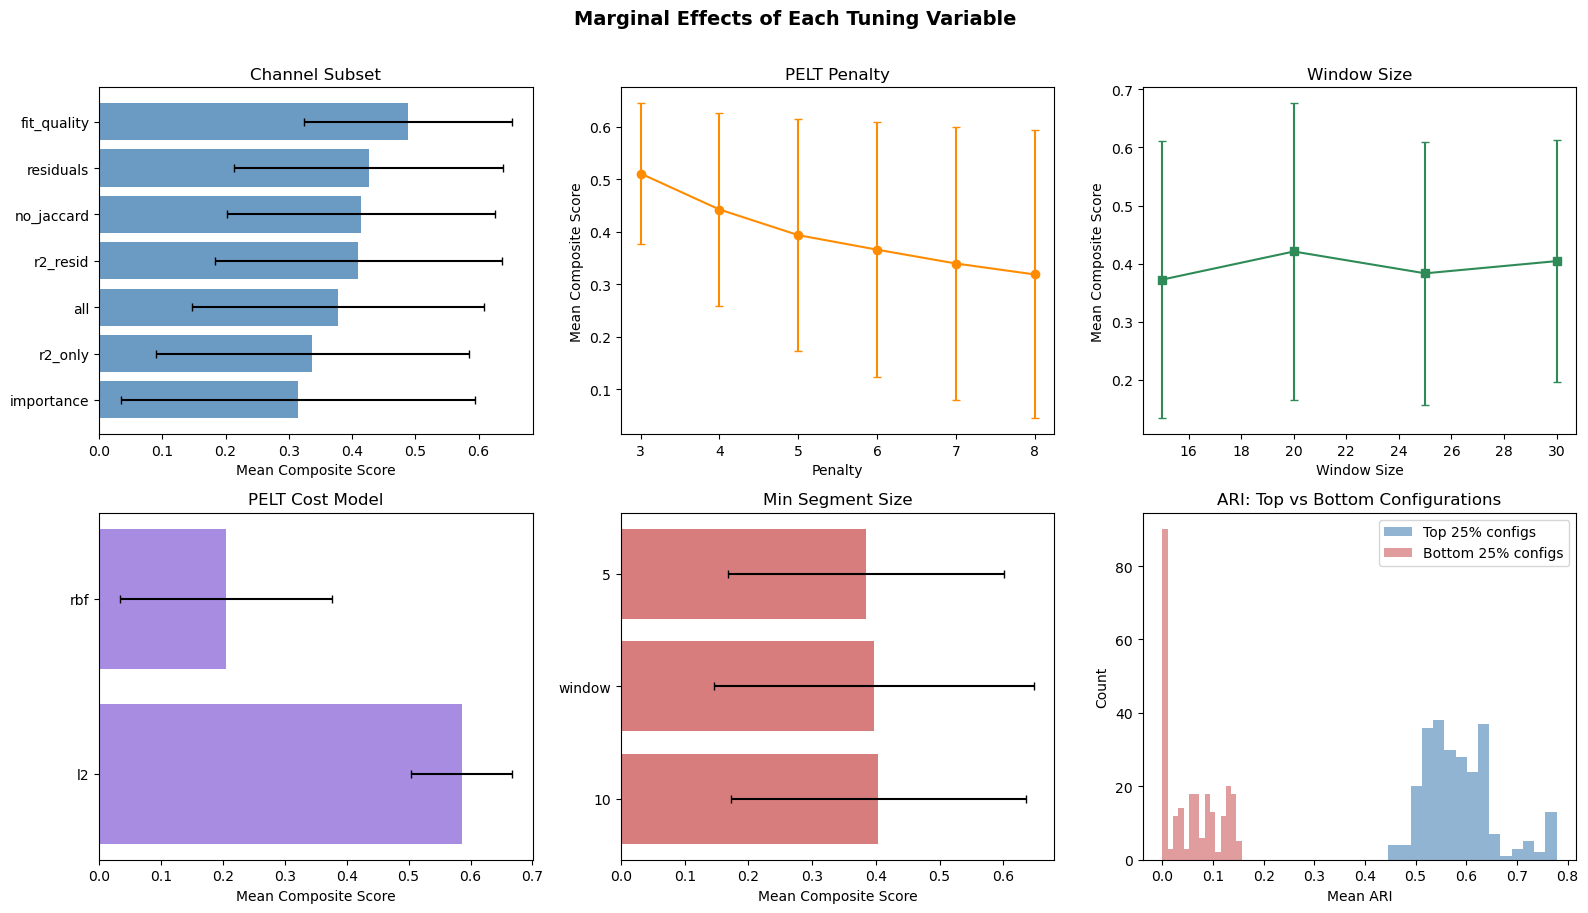

In [9]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))

# 1. Channels
ax = axes[0, 0]
marginal = agg.groupby("channels")["composite_mean"].agg(["mean", "std"]).sort_values("mean", ascending=False)
ax.barh(marginal.index, marginal["mean"], xerr=marginal["std"], capsize=3, color="steelblue", alpha=0.8)
ax.set_xlabel("Mean Composite Score")
ax.set_title("Channel Subset")
ax.invert_yaxis()

# 2. Penalty
ax = axes[0, 1]
marginal = agg.groupby("penalty")["composite_mean"].agg(["mean", "std"]).sort_index()
ax.errorbar(marginal.index, marginal["mean"], yerr=marginal["std"], marker="o", capsize=3, color="darkorange")
ax.set_xlabel("Penalty")
ax.set_ylabel("Mean Composite Score")
ax.set_title("PELT Penalty")

# 3. Window Size
ax = axes[0, 2]
marginal = agg.groupby("window_size")["composite_mean"].agg(["mean", "std"]).sort_index()
ax.errorbar(marginal.index, marginal["mean"], yerr=marginal["std"], marker="s", capsize=3, color="seagreen")
ax.set_xlabel("Window Size")
ax.set_ylabel("Mean Composite Score")
ax.set_title("Window Size")

# 4. PELT Model
ax = axes[1, 0]
marginal = agg.groupby("pelt_model")["composite_mean"].agg(["mean", "std"]).sort_values("mean", ascending=False)
ax.barh(marginal.index, marginal["mean"], xerr=marginal["std"], capsize=3, color="mediumpurple", alpha=0.8)
ax.set_xlabel("Mean Composite Score")
ax.set_title("PELT Cost Model")

# 5. Min Size
ax = axes[1, 1]
marginal = agg.groupby("min_size_opt")["composite_mean"].agg(["mean", "std"]).sort_values("mean", ascending=False)
ax.barh(marginal.index, marginal["mean"], xerr=marginal["std"], capsize=3, color="indianred", alpha=0.8)
ax.set_xlabel("Mean Composite Score")
ax.set_title("Min Segment Size")

# 6. ARI distribution for top vs bottom configs
ax = axes[1, 2]
top_25 = agg.head(len(agg) // 4)["ari_mean"]
bot_25 = agg.tail(len(agg) // 4)["ari_mean"]
ax.hist(top_25, bins=15, alpha=0.6, label="Top 25% configs", color="steelblue")
ax.hist(bot_25, bins=15, alpha=0.6, label="Bottom 25% configs", color="indianred")
ax.set_xlabel("Mean ARI")
ax.set_ylabel("Count")
ax.set_title("ARI: Top vs Bottom Configurations")
ax.legend()

plt.suptitle("Marginal Effects of Each Tuning Variable", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

## 8. Interaction Heatmaps

The marginal effects show the average influence of each variable, but the best
configuration depends on interactions (e.g., higher penalty might be optimal for
certain channel subsets but not others). These heatmaps show the two most important
two-way interactions.

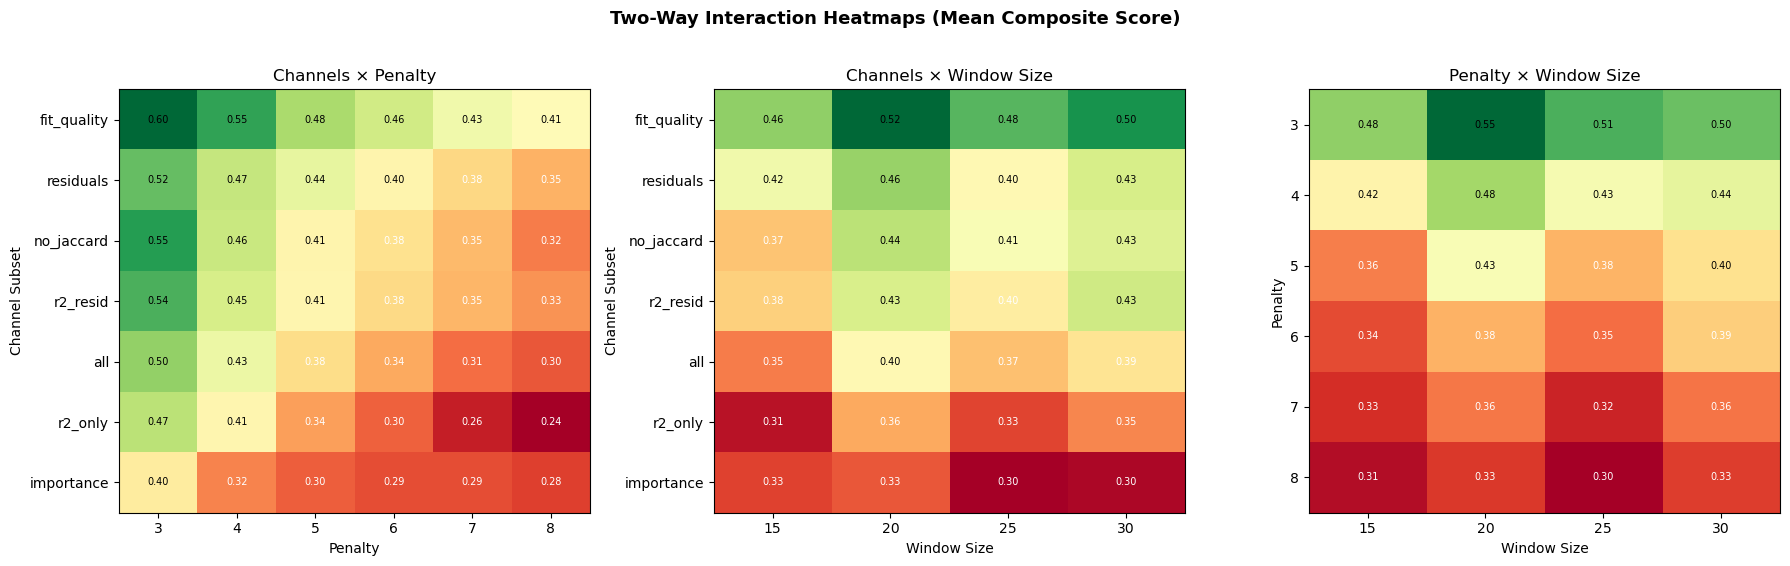

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))

# Heatmap 1: Channels × Penalty (most likely key interaction)
ax = axes[0]
pivot = agg.groupby(["channels", "penalty"])["composite_mean"].mean().unstack("penalty")
# Order channels by marginal mean
ch_order = agg.groupby("channels")["composite_mean"].mean().sort_values(ascending=False).index
pivot = pivot.loc[[c for c in ch_order if c in pivot.index]]
im = ax.imshow(pivot.values, aspect="auto", cmap="RdYlGn", vmin=pivot.values.min(), vmax=pivot.values.max())
ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels([f"{p:.0f}" for p in pivot.columns])
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels(pivot.index)
ax.set_xlabel("Penalty")
ax.set_ylabel("Channel Subset")
ax.set_title("Channels × Penalty")
for i in range(len(pivot.index)):
    for j in range(len(pivot.columns)):
        v = pivot.values[i, j]
        ax.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=7,
                color="white" if v < pivot.values.mean() else "black")

# Heatmap 2: Channels × Window Size
ax = axes[1]
pivot2 = agg.groupby(["channels", "window_size"])["composite_mean"].mean().unstack("window_size")
pivot2 = pivot2.loc[[c for c in ch_order if c in pivot2.index]]
im2 = ax.imshow(pivot2.values, aspect="auto", cmap="RdYlGn", vmin=pivot2.values.min(), vmax=pivot2.values.max())
ax.set_xticks(range(len(pivot2.columns)))
ax.set_xticklabels(pivot2.columns)
ax.set_yticks(range(len(pivot2.index)))
ax.set_yticklabels(pivot2.index)
ax.set_xlabel("Window Size")
ax.set_ylabel("Channel Subset")
ax.set_title("Channels × Window Size")
for i in range(len(pivot2.index)):
    for j in range(len(pivot2.columns)):
        v = pivot2.values[i, j]
        ax.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=7,
                color="white" if v < pivot2.values.mean() else "black")

# Heatmap 3: Penalty × Window Size
ax = axes[2]
pivot3 = agg.groupby(["penalty", "window_size"])["composite_mean"].mean().unstack("window_size")
im3 = ax.imshow(pivot3.values, aspect="auto", cmap="RdYlGn", vmin=pivot3.values.min(), vmax=pivot3.values.max())
ax.set_xticks(range(len(pivot3.columns)))
ax.set_xticklabels(pivot3.columns)
ax.set_yticks(range(len(pivot3.index)))
ax.set_yticklabels([f"{p:.0f}" for p in pivot3.index])
ax.set_xlabel("Window Size")
ax.set_ylabel("Penalty")
ax.set_title("Penalty × Window Size")
for i in range(len(pivot3.index)):
    for j in range(len(pivot3.columns)):
        v = pivot3.values[i, j]
        ax.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=7,
                color="white" if v < pivot3.values.mean() else "black")

plt.suptitle("Two-Way Interaction Heatmaps (Mean Composite Score)", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

## 9. Per-Seed Robustness of the Top Configurations

The top configs by mean composite might have high variance (lucky on some seeds,
bad on others). This section shows per-seed results for the top 5 configs to check
whether they're consistently good or just good on average.

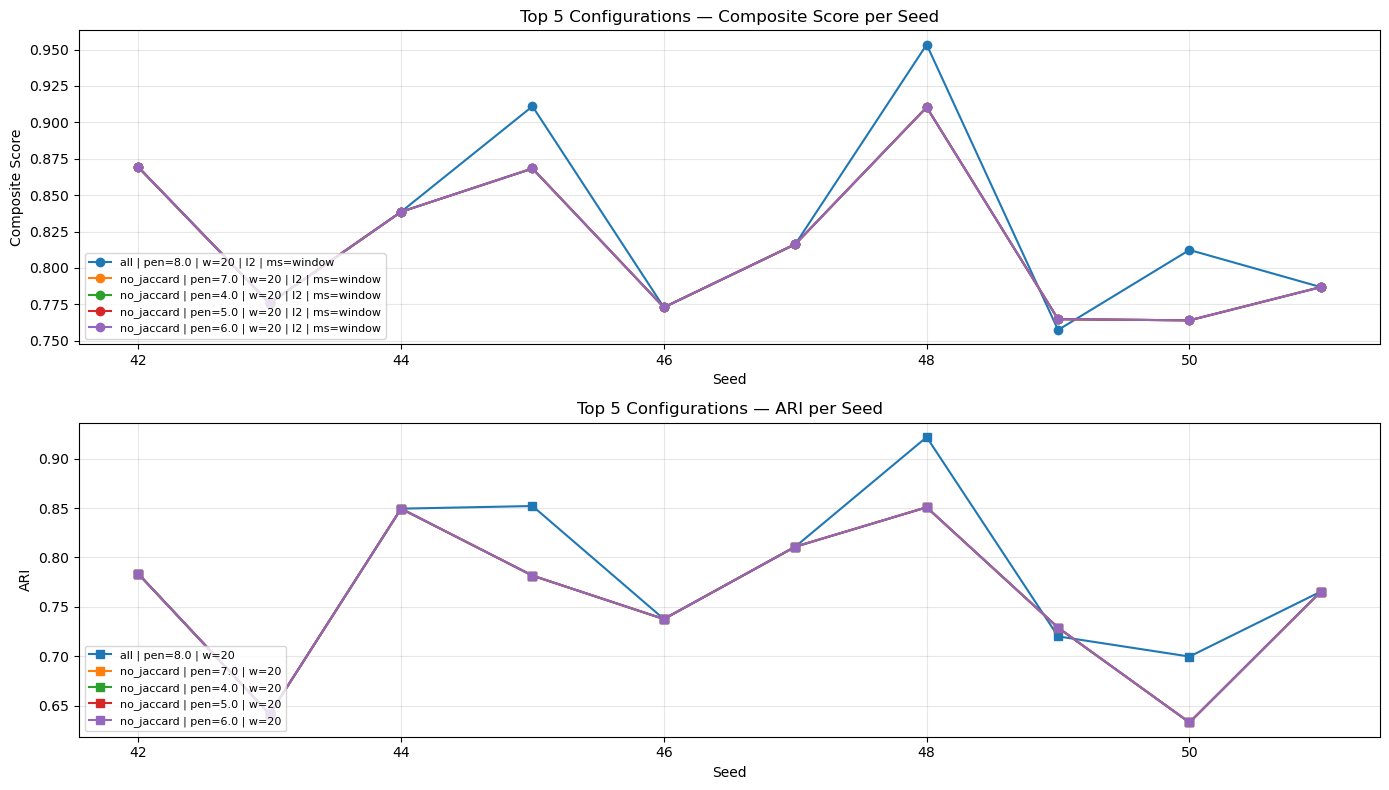


BEST CONFIGURATION DETAIL
  channels: all
  penalty: 8.0
  window_size: 20
  pelt_model: l2
  min_size_opt: window

Per-seed results:
  seed 42: ARI=0.784, loc_err=3.8, n_detected=4, composite=0.869
  seed 43: ARI=0.641, loc_err=7.5, n_detected=4, composite=0.776
  seed 44: ARI=0.849, loc_err=3.2, n_detected=5, composite=0.839
  seed 45: ARI=0.852, loc_err=2.5, n_detected=4, composite=0.911
  seed 46: ARI=0.738, loc_err=4.9, n_detected=5, composite=0.773
  seed 47: ARI=0.811, loc_err=3.8, n_detected=5, composite=0.816
  seed 48: ARI=0.922, loc_err=1.2, n_detected=4, composite=0.953
  seed 49: ARI=0.720, loc_err=6.0, n_detected=5, composite=0.757
  seed 50: ARI=0.700, loc_err=6.2, n_detected=4, composite=0.812
  seed 51: ARI=0.765, loc_err=4.9, n_detected=5, composite=0.787


In [11]:
# Get top 5 configs
top5 = agg.head(5)[group_cols].to_dict("records")

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Per-seed composite scores
ax = axes[0]
for i, cfg in enumerate(top5):
    mask = pd.Series(True, index=results_df.index)
    for col in group_cols:
        mask &= results_df[col] == cfg[col]
    seed_scores = results_df.loc[mask].sort_values("seed")
    label = f"{cfg['channels']} | pen={cfg['penalty']} | w={cfg['window_size']} | {cfg['pelt_model']} | ms={cfg['min_size_opt']}"
    ax.plot(seed_scores["seed"].values, seed_scores["composite"].values, "o-", label=label, linewidth=1.5)
ax.set_xlabel("Seed")
ax.set_ylabel("Composite Score")
ax.set_title("Top 5 Configurations — Composite Score per Seed")
ax.legend(fontsize=8, loc="lower left")
ax.grid(True, alpha=0.3)

# Per-seed ARI
ax = axes[1]
for i, cfg in enumerate(top5):
    mask = pd.Series(True, index=results_df.index)
    for col in group_cols:
        mask &= results_df[col] == cfg[col]
    seed_scores = results_df.loc[mask].sort_values("seed")
    label = f"{cfg['channels']} | pen={cfg['penalty']} | w={cfg['window_size']}"
    ax.plot(seed_scores["seed"].values, seed_scores["ari"].values, "s-", label=label, linewidth=1.5)
ax.set_xlabel("Seed")
ax.set_ylabel("ARI")
ax.set_title("Top 5 Configurations — ARI per Seed")
ax.legend(fontsize=8, loc="lower left")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print detailed per-seed stats for #1 config
best_cfg = top5[0]
print(f"\n{'='*70}")
print(f"BEST CONFIGURATION DETAIL")
print(f"{'='*70}")
for col in group_cols:
    print(f"  {col}: {best_cfg[col]}")
mask = pd.Series(True, index=results_df.index)
for col in group_cols:
    mask &= results_df[col] == best_cfg[col]
best_detail = results_df.loc[mask].sort_values("seed")
print(f"\nPer-seed results:")
for _, row in best_detail.iterrows():
    print(f"  seed {int(row['seed'])}: ARI={row['ari']:.3f}, "
          f"loc_err={row['location_error']:.1f}, "
          f"n_detected={int(row['n_detected'])}, "
          f"composite={row['composite']:.3f}")

## 10. Diagnostic Channel Visualisation (Best Config)

Show the rolling diagnostic traces for the best configuration on seed 42,
with true and detected boundaries overlaid. This gives a visual sanity check
on what the detector is "seeing" in the winning channel subset.

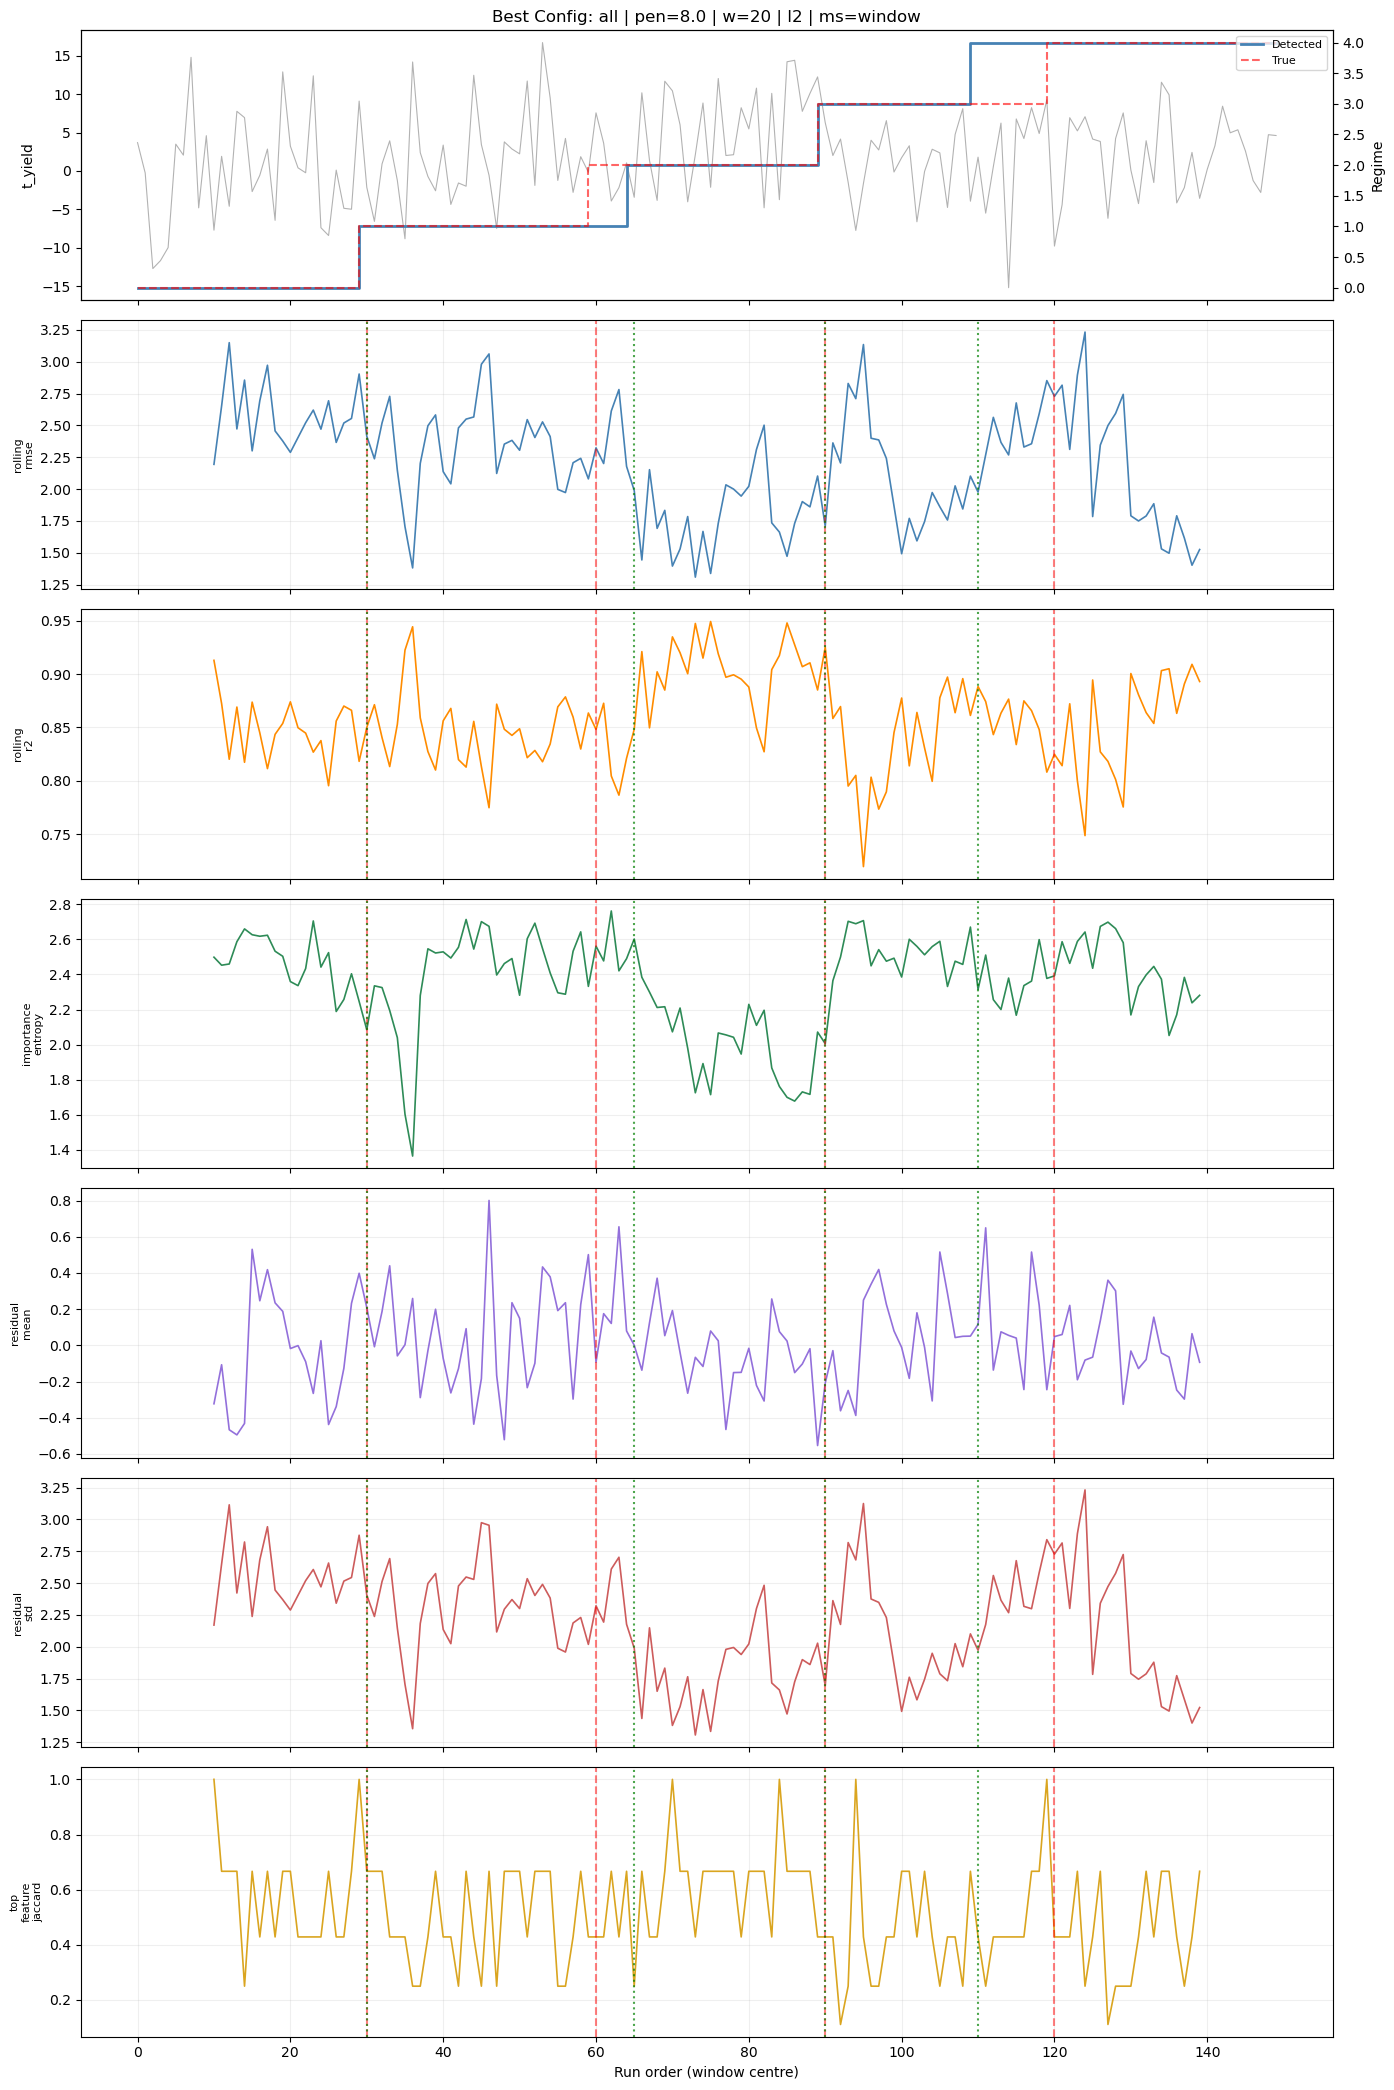

Detected boundaries: [30, 65, 90, 110]
True boundaries: [30, 60, 90, 120]
Metrics: ARI=0.784, loc_err=3.8, n_detected=4


In [12]:
# Run the best config on seed 42 and visualise
best = agg.iloc[0]
ws_best = int(best["window_size"])
pen_best = float(best["penalty"])
ch_best = CHANNEL_SUBSETS[best["channels"]]
pm_best = best["pelt_model"]
ms_best = ws_best if best["min_size_opt"] == "window" else int(best["min_size_opt"])

completed_42, fcols_42, true_42 = datasets[42]
diag_42 = diag_cache[(42, ws_best)]

labels_42, bounds_42 = run_pelt_on_cached(
    diag_42, len(completed_42), ch_best, pen_best, pm_best, ms_best, ws_best,
)

# Plot each channel in the winning subset
n_ch = len(ch_best)
fig, axes = plt.subplots(n_ch + 1, 1, figsize=(14, 3 * (n_ch + 1)), sharex=True)

# Top panel: yield + regime labels
ax = axes[0]
ax.plot(completed_42["t_yield"].values, alpha=0.6, linewidth=0.8, color="gray")
ax2 = ax.twinx()
ax2.step(range(len(labels_42)), labels_42, color="steelblue", linewidth=2, label="Detected")
ax2.step(range(len(true_42)), true_42, color="red", linewidth=1.5, linestyle="--", alpha=0.6, label="True")
ax2.set_ylabel("Regime")
ax2.legend(loc="upper right", fontsize=8)
ax.set_ylabel("t_yield")
ax.set_title(f"Best Config: {best['channels']} | pen={pen_best} | w={ws_best} | {pm_best} | ms={best['min_size_opt']}")

colors = ["steelblue", "darkorange", "seagreen", "mediumpurple", "indianred", "goldenrod"]
for i, ch in enumerate(ch_best):
    ax = axes[i + 1]
    ax.plot(diag_42["run_center"], diag_42[ch], color=colors[i % len(colors)], linewidth=1.2)
    for cp in TRUE_CHANGEPOINTS:
        ax.axvline(cp, color="red", linestyle="--", alpha=0.5)
    for bp in bounds_42:
        ax.axvline(bp, color="green", linestyle=":", alpha=0.7)
    ax.set_ylabel(ch.replace("_", "\n"), fontsize=8)
    ax.grid(True, alpha=0.2)

axes[-1].set_xlabel("Run order (window centre)")
plt.tight_layout()
plt.show()

print(f"Detected boundaries: {bounds_42}")
print(f"True boundaries: {TRUE_CHANGEPOINTS}")
m42 = evaluate_detection(labels_42, bounds_42, true_42)
print(f"Metrics: ARI={m42['ari']:.3f}, loc_err={m42['location_error']:.1f}, n_detected={m42['n_detected']}")

## 11. Detection Count Distribution

How often does each number of changepoints get detected? The ideal is 2.
This shows whether configurations tend to over-detect (too many spurious breaks)
or under-detect (missing real regime shifts).

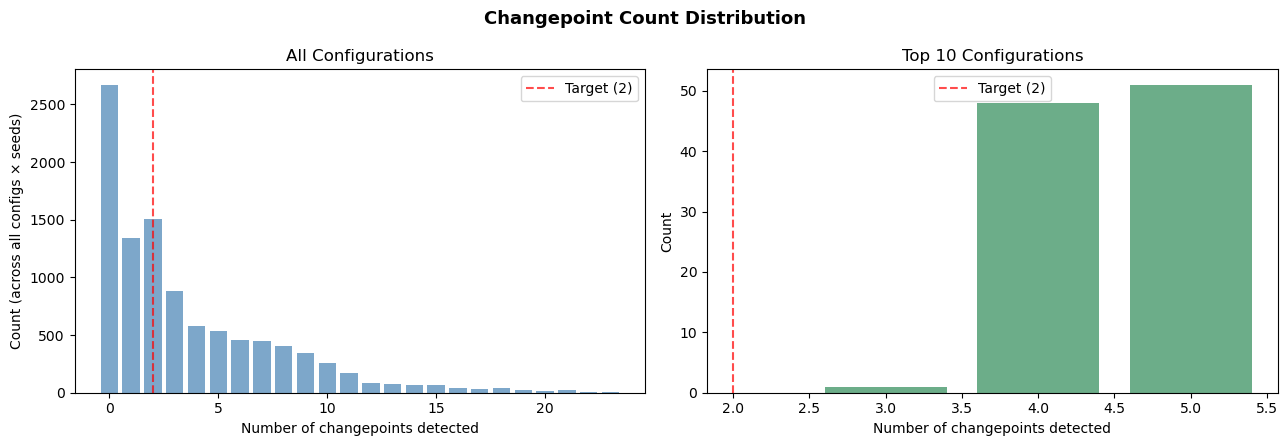

In [13]:
# Detection count distribution for top 10 vs all configs
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# All configs
ax = axes[0]
counts_all = results_df["n_detected"].value_counts().sort_index()
ax.bar(counts_all.index, counts_all.values, color="steelblue", alpha=0.7)
ax.axvline(2, color="red", linestyle="--", alpha=0.7, label="Target (2)")
ax.set_xlabel("Number of changepoints detected")
ax.set_ylabel("Count (across all configs × seeds)")
ax.set_title("All Configurations")
ax.legend()

# Top 10 configs only
ax = axes[1]
top10_cfgs = agg.head(10)
top10_mask = pd.Series(False, index=results_df.index)
for _, cfg_row in top10_cfgs.iterrows():
    mask = pd.Series(True, index=results_df.index)
    for col in group_cols:
        mask &= results_df[col] == cfg_row[col]
    top10_mask |= mask
counts_top = results_df.loc[top10_mask, "n_detected"].value_counts().sort_index()
ax.bar(counts_top.index, counts_top.values, color="seagreen", alpha=0.7)
ax.axvline(2, color="red", linestyle="--", alpha=0.7, label="Target (2)")
ax.set_xlabel("Number of changepoints detected")
ax.set_ylabel("Count")
ax.set_title("Top 10 Configurations")
ax.legend()

plt.suptitle("Changepoint Count Distribution", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

## 12. Summary & Recommendation

Print the final recommendation: the configuration to bring back to the prototype notebook.

In [14]:
# Final summary
best = agg.iloc[0]
runner_up = agg.iloc[1]

print("=" * 70)
print("REGIME DETECTION TUNING — FINAL RESULTS")
print("=" * 70)
print(f"\nGrid: {len(agg)} configurations tested across {N_SEEDS} seeds")
print(f"Total evaluations: {len(results_df)}")

print(f"\n--- BEST CONFIGURATION ---")
print(f"  Channels:    {best['channels']}  →  {CHANNEL_SUBSETS[best['channels']]}")
print(f"  Penalty:     {best['penalty']}")
print(f"  Window size: {int(best['window_size'])}")
print(f"  PELT model:  {best['pelt_model']}")
print(f"  Min size:    {best['min_size_opt']}")
print(f"\n  Composite:   {best['composite_mean']:.3f} ± {best['composite_std']:.3f}")
print(f"  ARI:         {best['ari_mean']:.3f} ± {best['ari_std']:.3f}")
print(f"  Loc error:   {best['location_error_mean']:.1f} ± {best['location_error_std']:.1f} runs")
print(f"  n_detected:  {best['n_detected_mean']:.1f} ± {best['n_detected_std']:.1f}")

print(f"\n--- RUNNER-UP ---")
print(f"  Channels:    {runner_up['channels']}  →  {CHANNEL_SUBSETS[runner_up['channels']]}")
print(f"  Penalty:     {runner_up['penalty']}")
print(f"  Window size: {int(runner_up['window_size'])}")
print(f"  PELT model:  {runner_up['pelt_model']}")
print(f"  Min size:    {runner_up['min_size_opt']}")
print(f"  Composite:   {runner_up['composite_mean']:.3f} ± {runner_up['composite_std']:.3f}")

print(f"\n--- MARGINAL WINNERS ---")
for var in group_cols:
    marginal = agg.groupby(var)["composite_mean"].mean()
    winner = marginal.idxmax()
    print(f"  {var:15s}:  {winner}  (mean composite = {marginal.max():.3f})")

print(f"\n{'='*70}")
print("ACTION: Take the best configuration above and update detect_regimes()")
print("in the prototype notebook with these parameters.")
print(f"{'='*70}")

REGIME DETECTION TUNING — FINAL RESULTS

Grid: 1008 configurations tested across 10 seeds
Total evaluations: 10080

--- BEST CONFIGURATION ---
  Channels:    all  →  ['rolling_rmse', 'rolling_r2', 'importance_entropy', 'residual_mean', 'residual_std', 'top_feature_jaccard']
  Penalty:     8.0
  Window size: 20
  PELT model:  l2
  Min size:    window

  Composite:   0.829 ± 0.064
  ARI:         0.778 ± 0.083
  Loc error:   4.4 ± 1.9 runs
  n_detected:  4.5 ± 0.5

--- RUNNER-UP ---
  Channels:    no_jaccard  →  ['rolling_rmse', 'rolling_r2', 'importance_entropy', 'residual_mean', 'residual_std']
  Penalty:     7.0
  Window size: 20
  PELT model:  l2
  Min size:    window
  Composite:   0.817 ± 0.052

--- MARGINAL WINNERS ---
  channels       :  fit_quality  (mean composite = 0.488)
  penalty        :  3.0  (mean composite = 0.511)
  window_size    :  20  (mean composite = 0.421)
  pelt_model     :  l2  (mean composite = 0.586)
  min_size_opt   :  10  (mean composite = 0.404)

ACTION: Tak

In [15]:
# Export raw results and aggregated summary for reference
results_df.to_csv("tuning_results_raw_hard.csv", index=False)
agg.to_csv("tuning_results_summary_hard.csv", index=False)
print(f"Exported: tuning_results_raw.csv ({len(results_df)} rows)")
print(f"Exported: tuning_results_summary.csv ({len(agg)} rows)")

Exported: tuning_results_raw.csv (10080 rows)
Exported: tuning_results_summary.csv (1008 rows)
